# PHQ-8 Depression Detection — CNN + Vanilla RNN (Regression)

**Architecture**: 2 convolutional blocks reduce the frequency axis while preserving the time axis, producing a sequence of CNN feature vectors that is fed into a single-layer vanilla RNN. The RNN's final hidden state is passed to an FC regression head.

**Motivation**: Unlike the simple CNN that collapses the entire spectrogram with adaptive pooling, this model retains temporal structure. The CNN acts as a local feature extractor per time frame; the RNN captures long-range temporal dependencies across frames.

**Input**: log-mel spectrograms `(1, 128, 801)` saved as `.npy` files.

**Target**: PHQ-8 score (continuous, 0–24).

**Sequence flow**:
```
(B, 1, 128, 801)
  → CNN blocks    → (B, 32, 16, 200)
  → reshape       → (B, 200, 512)   # 200 time steps, 512 features each
  → Vanilla RNN   → h_n: (B, 64)
  → FC head       → (B,)
```

## 1. Imports & Configuration

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [3]:
# Paths
BASE_DIR = Path("..") 
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV = PROCESSED_DIR / "segment_metadata.csv"
SPEC_ROOT = PROCESSED_DIR / "spectrograms"
SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "cnn_rnn"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Training hyper-parameters
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
CHECKPOINT_FREQ = 10
EARLY_STOPPING_PATIENCE = 10
NUM_WORKERS = 0

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("  WARNING: No GPU detected — training will be significantly slower.")
print(f"Checkpoints will be saved to: {SAVE_DIR.resolve()}")

Using device: cuda
Checkpoints will be saved to: C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\cnn_rnn


## 2. Dataset

In [4]:
def spec_augment(spec, n_freq_masks=2, freq_mask_width=10, n_time_masks=2, time_mask_width=50):
    """
    SpecAugment: randomly zero-out horizontal (frequency) and vertical (time)
    bands of a spectrogram.  Applied in-place on a (n_mels, n_frames) tensor.
    """
    n_mels, n_frames = spec.shape
    for _ in range(n_freq_masks):
        f = torch.randint(0, freq_mask_width + 1, (1,)).item()
        f0 = torch.randint(0, max(n_mels - f, 1), (1,)).item()
        spec[f0 : f0 + f, :] = 0.0
    for _ in range(n_time_masks):
        t = torch.randint(0, time_mask_width + 1, (1,)).item()
        t0 = torch.randint(0, max(n_frames - t, 1), (1,)).item()
        spec[:, t0 : t0 + t] = 0.0
    return spec

class SpectrogramDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, spec_root: Path, split: str):
        self.meta = meta_df.reset_index(drop=True)
        self.split_dir = spec_root / split
        self.augment = (split == "train")

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        pid = int(row["participant_id"])
        seg = int(row["segment_idx"])
        spec_path = self.split_dir / f"{pid}_seg{seg:04d}.npy"
        spec = np.load(spec_path).astype(np.float32)
        spec = torch.from_numpy(spec)                        # (128, n_frames)
        if self.augment:
            spec = spec_augment(spec)
        spec = spec.unsqueeze(0)                             # (1, 128, n_frames)
        label = torch.tensor(float(row["phq_score"]), dtype=torch.float32)
        pid_t = torch.tensor(pid, dtype=torch.long)
        return spec, label, pid_t                           # pid needed for participant-level aggregation

def build_loaders(meta_csv, spec_root, batch_size, num_workers):
    meta = pd.read_csv(meta_csv)
    splits = {}
    for split in ("train", "dev", "test"):
        df = meta[meta["split"] == split].reset_index(drop=True)
        ds = SpectrogramDataset(df, spec_root, split)
        splits[split] = DataLoader(
            ds, batch_size=batch_size, shuffle=(split == "train"),
            num_workers=num_workers, pin_memory=True
        )
        display_name = "validation" if split == "dev" else split
        aug_str = " + SpecAugment" if ds.augment else ""
        print(f"  {display_name:10s}: {len(df):6,} segments{aug_str}  →  {ds.split_dir}")
    return splits

print("Building data loaders…")
loaders      = build_loaders(META_CSV, SPEC_ROOT, BATCH_SIZE, NUM_WORKERS)
train_loader = loaders["train"]
val_loader   = loaders["dev"]
test_loader  = loaders["test"]

Building data loaders…
  train     : 11,362 segments + SpecAugment  →  ..\processed\spectrograms\train
  validation:  4,322 segments  →  ..\processed\spectrograms\dev
  test      :  5,904 segments  →  ..\processed\spectrograms\test


## 3. Model — CNN Feature Extractor + Vanilla RNN

In [5]:
class CNNRNNRegressor(nn.Module):
    """
    CNN feature extractor followed by a vanilla RNN for PHQ-8 regression.

    The CNN applies two convolutional blocks with pooling that collapses the
    frequency axis while down-sampling the time axis only moderately.  The
    result is reshaped into a sequence (one vector per time step) and fed
    into a single-layer vanilla RNN.  The final hidden state is projected to
    a scalar PHQ-8 prediction.

    Tensor flow
    -----------
    Input  : (B, 1, 128, 801)   — log-mel spectrogram
    Block 1: MaxPool2d(2,2)  →  (B, 16, 64, 400)
    Block 2: MaxPool2d(4,2)  →  (B, 32, 16, 200)
    Reshape :                →  (B, 200, 512)    # T=200, feat=32×16
    RNN     :                →  h_n (B, 64)
    FC head :                →  (B,)
    """

    def __init__(self, rnn_hidden: int = 64, rnn_layers: int = 1, dropout: float = 0.5):
        super().__init__()

        # ── CNN blocks ────────────────────────────────────────────────────
        # MaxPool stride (freq, time): reduces freq aggressively, time gently
        self.cnn = nn.Sequential(
            # Block 1: (B, 1, 128, 801) → (B, 16, 64, 400)
            nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),
            # Block 2: (B, 16, 64, 400) → (B, 32, 16, 200)
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(4, 2), stride=(4, 2)),
        )
        # After CNN: (B, 32, 16, 200)
        # Reshape  : (B, 200, 512)  — 200 time steps, each with 32×16=512 features
        cnn_feat = 32 * 16  # 512

        # ── Vanilla RNN ───────────────────────────────────────────────────
        self.rnn = nn.RNN(
            input_size=cnn_feat,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            nonlinearity="tanh",
            batch_first=True,
            # RNN dropout only applies between layers; ignored for single-layer
            dropout=dropout if rnn_layers > 1 else 0.0,
        )

        # ── FC regression head ────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(rnn_hidden, 1),
        )

    def forward(self, x):
        # x: (B, 1, 128, 801)
        x = self.cnn(x)                     # (B, 32, 16, 200)
        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2)          # (B, T, C, F)
        x = x.reshape(B, T, C * F)         # (B, T, 512)  — sequence for RNN
        _, h_n = self.rnn(x)               # h_n: (num_layers, B, hidden)
        h = h_n[-1]                         # (B, hidden)  — last layer, last step
        out = self.head(h)                  # (B, 1)
        return out.squeeze(1)               # (B,)

model = CNNRNNRegressor(rnn_hidden=64, rnn_layers=1, dropout=0.5).to(DEVICE)

with torch.no_grad():
    dummy = torch.zeros(2, 1, 128, 801, device=DEVICE)
    out   = model(dummy)
    print(f"Output shape: {out.shape}  (expected: (2,))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape: torch.Size([2])  (expected: (2,))
Trainable parameters: 41,905


## 4. Training Loop

In [6]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "val_loss": [], "val_rmse": []}
best_val_loss = float("inf")
epochs_no_improve = 0

def train_epoch(loader):
    """Segment-level training pass."""
    model.train()
    total_loss, total_samples = 0.0, 0
    for specs, labels, _ in loader:
        specs  = specs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        preds  = model(specs)
        loss   = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * len(labels)
        total_samples += len(labels)
    return total_loss / total_samples

def evaluate_participant(loader):
    """
    Participant-level evaluation.
    Runs inference on every segment, then averages each participant's
    segment predictions into one score before computing metrics.
    """
    model.eval()
    records = []
    with torch.no_grad():
        for specs, labels, pids in loader:
            specs = specs.to(DEVICE, non_blocking=True)
            preds = model(specs).cpu().numpy()
            for pid, pred, label in zip(pids.numpy(), preds, labels.numpy()):
                records.append((int(pid), float(pred), float(label)))

    df = pd.DataFrame(records, columns=["participant_id", "pred", "label"])
    agg = df.groupby("participant_id").agg(
        pred  = ("pred",  "mean"),
        label = ("label", "first"),
    ).reset_index()

    mse  = float(np.mean((agg["pred"].values - agg["label"].values) ** 2))
    rmse = mse ** 0.5
    return mse, rmse, agg

for epoch in range(1, NUM_EPOCHS + 1):

    train_mse = train_epoch(train_loader)
    val_mse, val_rmse, _ = evaluate_participant(val_loader)

    history["train_loss"].append(train_mse)
    history["val_loss"].append(val_mse)
    history["val_rmse"].append(val_rmse)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}], Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}, Val RMSE: {val_rmse:.4f}")

    # Checkpoint
    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_cnn_rnn.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "val_mse":              val_mse,
        }, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path.name}")

    # Save best / early stopping (participant-level val MSE)
    if val_mse < best_val_loss:
        best_val_loss     = val_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "cnn_rnn_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_mse":              val_mse,
            "val_rmse":             val_rmse,
        }, best_path)
        print(f"  Best model saved -> {best_path.name}  (val MSE {val_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered — no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best val MSE (participant) : {best_val_loss:.4f}  |  RMSE : {best_val_loss**0.5:.4f}")

Epoch [1/100], Train MSE: 37.7784, Val MSE: 50.9751, Val RMSE: 7.1397
  Best model saved -> cnn_rnn_best.pth  (val MSE 50.9751)
Epoch [2/100], Train MSE: 30.6784, Val MSE: 47.3974, Val RMSE: 6.8846
  Best model saved -> cnn_rnn_best.pth  (val MSE 47.3974)
Epoch [3/100], Train MSE: 29.7366, Val MSE: 45.6524, Val RMSE: 6.7567
  Best model saved -> cnn_rnn_best.pth  (val MSE 45.6524)
Epoch [4/100], Train MSE: 29.3705, Val MSE: 44.7801, Val RMSE: 6.6918
  Best model saved -> cnn_rnn_best.pth  (val MSE 44.7801)
Epoch [5/100], Train MSE: 29.1816, Val MSE: 44.3902, Val RMSE: 6.6626
  Best model saved -> cnn_rnn_best.pth  (val MSE 44.3902)
Epoch [6/100], Train MSE: 29.1109, Val MSE: 44.2554, Val RMSE: 6.6525
  Best model saved -> cnn_rnn_best.pth  (val MSE 44.2554)
Epoch [7/100], Train MSE: 29.0609, Val MSE: 44.1706, Val RMSE: 6.6461
  Best model saved -> cnn_rnn_best.pth  (val MSE 44.1706)
Epoch [8/100], Train MSE: 29.1247, Val MSE: 44.1048, Val RMSE: 6.6411
  Best model saved -> cnn_rnn_best

## 5. Training Curves

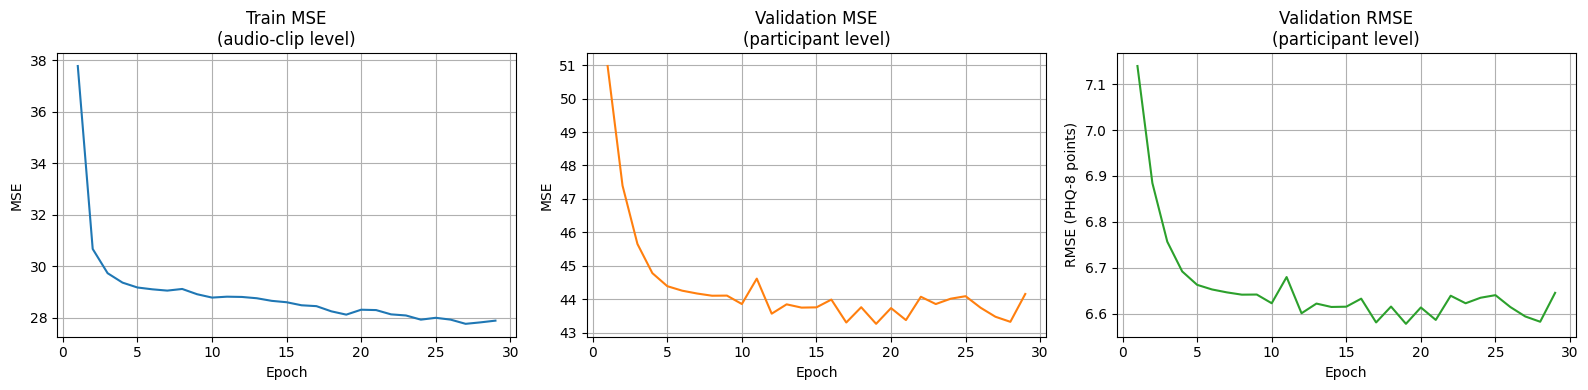

In [7]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history["train_loss"], color="tab:blue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Train MSE\n(audio-clip level)")
axes[0].grid(True)

axes[1].plot(epochs, history["val_loss"], color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Validation MSE\n(participant level)")
axes[1].grid(True)

axes[2].plot(epochs, history["val_rmse"], color="tab:green")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE (PHQ-8 points)")
axes[2].set_title("Validation RMSE\n(participant level)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluation on Test Set

Loads the best checkpoint and reports participant-level MSE, RMSE, MAE, and Pearson r.
Each participant's segment predictions are averaged into a single score before computing metrics.

In [8]:
# Load best weights
best_ckpt = torch.load(SAVE_DIR / "cnn_rnn_best.pth", map_location=DEVICE, weights_only=True)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(val MSE {best_ckpt['val_mse']:.4f})")

# Participant-level predictions on test set
_, _, test_agg = evaluate_participant(test_loader)

all_preds  = test_agg["pred"].values
all_labels = test_agg["label"].values

print(f"  Participants evaluated: {len(test_agg)}")

# Metrics
test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print("\n── Test-set results (participant level) ───────────")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

Loaded best model from epoch 19  (val MSE 43.2641)
  Participants evaluated: 47

── Test-set results (participant level) ───────────
  MSE       : 41.7726
  RMSE      : 6.4632  PHQ-8 points
  MAE       : 5.3768  PHQ-8 points
  Pearson r : 0.0091


## 7. Prediction Distribution

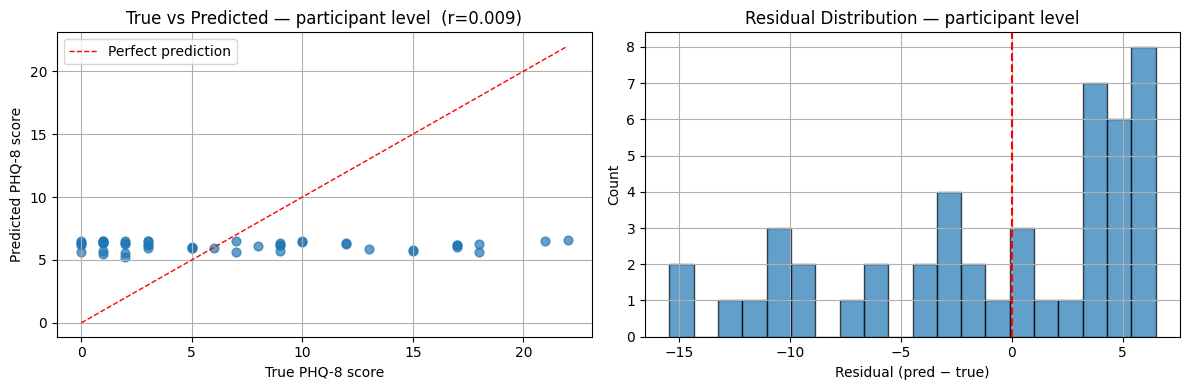

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One point per participant
axes[0].scatter(all_labels, all_preds, alpha=0.7, s=40)
lo, hi = min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted — participant level  (r={test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

residuals = all_preds - all_labels
axes[1].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — participant level")
axes[1].grid(True)

plt.tight_layout()
plt.show()